<a href="https://colab.research.google.com/github/simon19891101/ML_experiments/blob/main/RQ_VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras import backend as K

import string

from openai import OpenAI
from google.colab import userdata

import json

import matplotlib.pyplot as plt
from collections import Counter

import itertools

### Create RQ-VAE

In [ ]:
# ---------------------------
# Residual Quantizer Layer
# ---------------------------
class ResidualQuantizer(layers.Layer):
    """
    Residual vector quantizer (RQ) for (batch, dim) inputs.
    Args:
      num_quantizers: number of residual quantizers (stages)
      codebook_size: entries per codebook
      dim: latent dimensionality
      commitment_cost: weight for commitment loss
    Returns:
      quantized: tensor same shape as inputs
      loss: dictionary with 'codebook_loss' and 'commitment_loss'
      indices_list: list of argmin indices for each quantizer stage (for retrieval)
    """
    def __init__(self,
                 num_quantizers: int,
                 codebook_size: int,
                 dim: int,
                 commitment_cost: float = 0.25,
                 **kwargs):
        super().__init__(**kwargs)
        self.num_q = int(num_quantizers)
        self.K = int(codebook_size)
        self.dim = int(dim)
        self.beta = float(commitment_cost)

        # Create codebooks as trainable variables: shape (num_q, K, dim)
        # Use initializer close to 0, small std.
        init = tf.random_normal_initializer(stddev=0.02)
        self.codebooks = [
            self.add_weight(
                name=f'codebook_{i}',
                shape=(self.K, self.dim),
                initializer=init,
                trainable=True,
                dtype=tf.float32
            )
            for i in range(self.num_q)
        ]

    def call(self, inputs, training=None):
        # inputs: (batch, dim)
        x = tf.convert_to_tensor(inputs, dtype=tf.float32)
        batch = tf.shape(x)[0]

        residual = x  # residual to quantize
        quantized_total = tf.zeros_like(x)
        codebook_loss = 0.0
        commitment_loss = 0.0
        indices_list = []

        for i in range(self.num_q):
            cb = self.codebooks[i]            # (K, dim)
            # compute squared distances: (batch, K)
            # expand dims for broadcasting
            # dist = ||residual - cb_k||^2 = ||residual||^2 + ||cb_k||^2 - 2*residual·cb_k
            r2 = tf.reduce_sum(tf.square(residual), axis=1, keepdims=True)  # (B,1)
            cb2 = tf.reduce_sum(tf.square(cb), axis=1)  # (K,)
            # compute dot product
            dot = tf.matmul(residual, cb, transpose_b=True)  # (B, K)
            # distances
            distances = r2 + tf.reshape(cb2, (1, -1)) - 2.0 * dot  # (B, K)

            # find argmin
            indices = tf.argmin(distances, axis=1)  # (B,)
            indices_list.append(indices)

            # one-hot
            one_hot = tf.one_hot(indices, depth=self.K, dtype=tf.float32)  # (B,K)
            # quantized vectors: (B, dim) = one_hot @ cb
            quantized = tf.matmul(one_hot, cb)  # (B, dim)

            # accumulate quantized output and update residual
            quantized_total += quantized
            residual = residual - quantized  # new residual for next stage

            # losses for this stage:
            # codebook loss (move codebook towards encoder outputs): ||sg(residual_before) - q||^2
            # commitment loss (encourage encoder outputs to commit to codebook): ||res_before - sg(q)||^2
            # For codebook loss we use stop_gradient on residual_before so gradients go to cb only.
            # For commitment loss we use stop_gradient on quantized so gradients go to encoder only.
            # Note: residual_before = x - summed_previous_quantized. For easier bookkeeping,
            # compute residual_before_stage = residual + quantized (since residual already updated).
            residual_before = residual + quantized  # (B, dim)

            codebook_loss += tf.reduce_mean(tf.square(tf.stop_gradient(residual_before) - quantized))
            commitment_loss += tf.reduce_mean(tf.square(residual_before - tf.stop_gradient(quantized)))

        # Straight-through estimator: allow gradients to encoder, but treat quantized_total as discrete in backward path
        # z_q = x + stop_grad(quantized_total - x)
        z_q = x + tf.stop_gradient(quantized_total - x)

        losses = {
            "codebook_loss": codebook_loss,
            "commitment_loss": commitment_loss * self.beta
        }

        return z_q, losses, indices_list

# ---------------------------
# RQEmbeddingVAE (Encoder, Quantizer, Decoder)
# ---------------------------
class RQEmbeddingVAE(keras.Model):
    def __init__(self,
                 embedding_dim: int,
                 latent_dim: int,
                 num_quantizers: int = 2,
                 codebook_size: int = 512,
                 commitment_cost: float = 0.25,
                 **kwargs):
        super().__init__(**kwargs)
        self.embedding_dim = embedding_dim
        self.latent_dim = latent_dim

        # Encoder: project embedding_dim -> latent_dim
        self.encoder = keras.Sequential([
            layers.InputLayer(input_shape=(embedding_dim,)),
            layers.Dense(latent_dim, activation='relu')
        ])

        # Residual Quantizer
        self.quantizer = ResidualQuantizer(num_quantizers=num_quantizers,
                                           codebook_size=codebook_size,
                                           dim=latent_dim,
                                           commitment_cost=commitment_cost)

        # Decoder: latent_dim -> embedding_dim
        self.decoder = keras.Sequential([
            layers.InputLayer(input_shape=(latent_dim,)),
            layers.Dense(embedding_dim)
        ])

        # track metrics
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.codebook_loss_tracker = keras.metrics.Mean(name="codebook_loss")
        self.commitment_loss_tracker = keras.metrics.Mean(name="commitment_loss")
        self.total_loss_tracker = keras.metrics.Mean(name="loss")

    def call(self, inputs, training=False):
        z_e = self.encoder(inputs)                # (B, latent_dim)
        z_q, losses, indices = self.quantizer(z_e, training=training)  # quantized latent
        recon = self.decoder(z_q)                 # reconstruct embedding
        return recon, z_e, z_q, losses, indices

    @property
    def metrics(self):
        return [self.recon_loss_tracker,
                self.codebook_loss_tracker,
                self.commitment_loss_tracker,
                self.total_loss_tracker]

    def train_step(self, data):
        # data is either (x,) or x
        if isinstance(data, tuple) or isinstance(data, list):
            x = data[0]
        else:
            x = data

        with tf.GradientTape() as tape:
            recon, z_e, z_q, losses, indices = self.call(x, training=True)
            recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(recon - x), axis=1))  # MSE per sample then mean
            codebook_loss = losses["codebook_loss"]
            commitment_loss = losses["commitment_loss"]

            total_loss = recon_loss + codebook_loss + commitment_loss

        # compute grads and apply
        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        # update metrics
        self.recon_loss_tracker.update_state(recon_loss)
        self.codebook_loss_tracker.update_state(codebook_loss)
        self.commitment_loss_tracker.update_state(commitment_loss)
        self.total_loss_tracker.update_state(total_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "codebook_loss": self.codebook_loss_tracker.result(),
            "commitment_loss": self.commitment_loss_tracker.result()
        }

    def encode(self, inputs):
        z_e = self.encoder(inputs)
        _, _, indices = self.quantizer(z_e, training=False)
        return indices  # list of per-stage index tensors

    def decode_from_indices(self, indices_list):
        # build quantized vector from codebook indices (use first codebook as example)
        # This helper reconstructs the quantized latent given indices_list
        batch = tf.shape(indices_list[0])[0]
        quantized_total = tf.zeros((batch, self.latent_dim), dtype=tf.float32)
        for i, idx in enumerate(indices_list):
            cb = self.quantizer.codebooks[i]  # (K, dim)
            one_hot = tf.one_hot(idx, depth=self.quantizer.K, dtype=tf.float32)
            quantized = tf.matmul(one_hot, cb)
            quantized_total += quantized
        return self.decoder(quantized_total)

### Create Synthetic data

In [ ]:
client = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))

def chat_completion_request(messages, tools=None, tool_choice=None, model="gpt-4o-mini"):
    try:
        response = client.chat.completions.create(
            model=model,
            messages=messages,
            temperature=2,
            max_tokens=500,
            top_p=0.95,
            frequency_penalty=0,
            presence_penalty=0,
            stop=None,
            logprobs=False,
            #top_logprobs=2,
            n=1,
            response_format={"type": "json_object"}
        )
        return response
    except Exception as e:
        print("Unable to generate ChatCompletion response")
        print(f"Exception: {e}")
        return e

In [ ]:
dummy_data = []

for i in range(100):

  random_product = str(np.random.choice(['bottle', 'hat', 'carpet']))

  messages = []
  messages.append({"role": "system", "content": "You are synthetic data generator that creates product descriptions."})
  messages.append({"role": "user", "content": f"Generate one product in this category: {random_product}"})
  messages.append({"role": "user", "content": "The description covers product name, color, durability, size, and material."})
  messages.append({"role": "user", "content": f"Output is a json with keys including product_name, color, durability, size, material"})
  response = chat_completion_request(messages)
  response_json = json.loads(response.choices[0].message.content)
  response_json.update({'category': random_product})
  dummy_data.append(response_json)

In [ ]:
dummy_data = pd.DataFrame(dummy_data)
dst_file = "/content/drive/MyDrive/AI/df_products.csv"
dummy_data.to_csv(dst_file, index=False)

In [ ]:
dst_file = "/content/drive/MyDrive/AI/df_products.csv"

dummy_data = pd.read_csv(dst_file)

In [ ]:
dummy_data.sample(5).to_dict(orient='records')

[{'product_name': 'Classic Cotton Baseball Cap',
  'color': 'Navy Blue',
  'durability': 'High durability for everyday wear',
  'size': 'Adjustable, fits head sizes 22-24 inches',
  'material': '100% Cotton with a breathable inner lining',
  'category': 'hat'},
 {'product_name': 'EcoFlex Reusable Water Bottle',
  'color': 'Ocean Blue',
  'durability': 'Ultra-Durable, Resistant to Impact and Cracking',
  'size': '500ml',
  'material': 'BPA-Free Tritan Plastic',
  'category': 'bottle'},
 {'product_name': 'Luxora SoftTouch Area Rug',
  'color': 'Slate Gray',
  'durability': 'High-traffic durable fibers for long-lasting use',
  'size': '5 x 7 feet',
  'material': '100% Polypropylene, with a soft plush pile',
  'category': 'carpet'},
 {'product_name': 'Classic Cotton Bucket Hat',
  'color': 'Navy Blue',
  'durability': 'Highly Durable for Everyday Wear',
  'size': 'One Size Fits Most',
  'material': '100% Soft Cotton',
  'category': 'hat'},
 {'product_name': 'Classic Fedora Hat',
  'color':

In [ ]:
dummy_data['category'].value_counts()

,count
category,
bottle,37
carpet,33
hat,30


In [ ]:
dummy_data.duplicated().mean()

np.float64(0.0)

In [ ]:
dummy_data.nunique()

,0
product_name,86
color,42
durability,96
size,60
material,83
category,3


In [ ]:
dummy_data_str = dummy_data['product_name']+','+dummy_data['color']+','+dummy_data['durability']+','+dummy_data['size']+','+dummy_data['material']

In [ ]:
dummy_data_str.values[0:3]

array(["LuxWeave UltraSoft Area Rug,Navy Blue,High Traffic,5' x 7',Polyester Blend",
       "Elegant Comfort Luxury Shag Area Rug,Cream,Highly Durable; Suitable for High Traffic Areas,5' x 7',Polyester Blend with Anti-Skid Backing",
       'Luxure Soft Pile Carpet,Warm Beige,High Traffic, Stain Resistant,12 feet x 15 feet,100% Nylon with a Plush Texture'],
      dtype=object)

### Create text embeddings and Semantic IDs

In [ ]:
from sentence_transformers import SentenceTransformer

# Example: all-MiniLM-L6-v2 is a small but strong model
emb_model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
embeddings = emb_model.encode(dummy_data_str, show_progress_bar=True)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
embeddings.shape

(100, 384)

## Train RQ-VAE

In [ ]:
K.clear_session()

embedding_dim = embeddings.shape[1]
latent_dim = 32

ds = tf.data.Dataset.from_tensor_slices(embeddings).shuffle(2048).batch(64)

model = RQEmbeddingVAE(
    embedding_dim=embedding_dim,
    latent_dim=latent_dim,
    num_quantizers=3,
    codebook_size=10,
    commitment_cost=0.25
)

model.compile(optimizer=keras.optimizers.Adam(1e-3))

model.fit(ds, epochs=200)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - codebook_loss: 0.0052 - commitment_loss: 0.0013 - loss: 1.0665 - recon_loss: 1.0599
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - codebook_loss: 0.0040 - commitment_loss: 9.9747e-04 - loss: 0.9937 - recon_loss: 0.9887
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - codebook_loss: 0.0034 - commitment_loss: 8.4898e-04 - loss: 0.9351 - recon_loss: 0.9308
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - codebook_loss: 0.0034 - commitment_loss: 8.4263e-04 - loss: 0.8852 - recon_loss: 0.8810
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - codebook_loss: 0.0038 - commitment_loss: 9.5737e-04 - loss: 0.8407 - recon_loss: 0.8359
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - codebook_loss: 0.0050 - commitment_loss: 0.0012 - loss: 0.7985 - recon_loss: 0.7923
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - codebook_loss: 0.0065 - commitment_loss: 0.0016 - loss: 0.7579 - recon_loss: 0.7497
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/st

In [ ]:
dummy_data.head(2)

,product_name,color,durability,size,material,category
0,LuxWeave UltraSoft Area Rug,Navy Blue,High Traffic,5' x 7',Polyester Blend,carpet
1,Elegant Comfort Luxury Shag Area Rug,Cream,Highly Durable; Suitable for High Traffic Areas,5' x 7',Polyester Blend with Anti-Skid Backing,carpet


## Perturbation test
Define sample space for each attribute

In [ ]:
product_name = dummy_data['product_name'].unique()
color = dummy_data['color'].unique()
durability = dummy_data['durability'].unique()
size = dummy_data['size'].unique()
material = dummy_data['material'].unique()

perturb_dict = {'product_name': product_name,
                'color': color,
                'durability': durability,
                'size': size,
                'material':material}

### Change 1 attribute

In [ ]:
perturb_columns = [['product_name'], ['color'],	['durability'],	['size'],	['material']]
N_perturb = 5
perturb_result_1 = {}

for perturb_col in perturb_columns:

  key = '+'.join(perturb_col)
  print(f'Purterbation: {key}')

  vae_code_change = []

  for ix in range(len(dummy_data)):

    dummy_input = dummy_data.drop(columns=['category']).iloc[ix].copy()
    dummy_input_str = ','.join(dummy_input.values)
    dummy_embedding = emb_model.encode(dummy_input_str).reshape(1,-1)
    dummy_codes = np.array([i.numpy()[0] for i in model.encode(dummy_embedding)])

    for i in range(N_perturb):
      perturb_field = []
      mod_input_str = dummy_input_str
      for j in range(len(perturb_col)):
        mod_field = dummy_input[perturb_col[j]]
        perturb_field = np.random.choice(perturb_dict[perturb_col[j]])
        mod_input_str = mod_input_str.replace(mod_field, perturb_field)

      mod_embedding = emb_model.encode(mod_input_str).reshape(1,-1)
      mod_codes = np.array([i.numpy()[0] for i in model.encode(mod_embedding)])
      diff_codes = np.where(dummy_codes != mod_codes)[0]
      diff_codes += 1
      vae_code_change.append(diff_codes)

  perturb_result_1.update({key: vae_code_change})

Purterbation: product_name
Purterbation: color
Purterbation: durability
Purterbation: size
Purterbation: material


In [ ]:
def get_perturb_result(perturb_columns, dummy_data=dummy_data, emb_model=emb_model, model=model, perturb_dict=perturb_dict, N_perturb = 5):

  perturb_result = {}

  for perturb_col in perturb_columns:

    key = '+'.join(perturb_col)
    print(f'Purterbation: {key}')

    vae_code_change = []

    for ix in range(len(dummy_data)):

      dummy_input = dummy_data.drop(columns=['category']).iloc[ix].copy()
      dummy_input_str = ','.join(dummy_input.values)
      dummy_embedding = emb_model.encode(dummy_input_str).reshape(1,-1)
      dummy_codes = np.array([i.numpy()[0] for i in model.encode(dummy_embedding)])

      for i in range(N_perturb):
        perturb_field = []
        mod_input_str = dummy_input_str
        for j in range(len(perturb_col)):
          mod_field = dummy_input[perturb_col[j]]
          perturb_field = np.random.choice(perturb_dict[perturb_col[j]])
          mod_input_str = mod_input_str.replace(mod_field, perturb_field)

        mod_embedding = emb_model.encode(mod_input_str).reshape(1,-1)
        mod_codes = np.array([i.numpy()[0] for i in model.encode(mod_embedding)])
        diff_codes = np.where(dummy_codes != mod_codes)[0]
        diff_codes += 1
        vae_code_change.append(diff_codes)

    perturb_result.update({key: vae_code_change})

  return perturb_result


def plot_purterbation_result(perturb_result, labels = [1, 2, 3], n_cols=3, figsize=(15, 10)):

  # Number of plots = number of keys
  n_plots = len(perturb_result)
  n_cols = n_cols
  n_rows = (n_plots + n_cols - 1) // n_cols  # ceiling division

  fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
  axes = axes.flatten()

  for i, (key, values) in enumerate(perturb_result.items()):

    # Count in how many arrays each label appears
    counts = []
    for label in labels:
        count = sum(label in arr for arr in values)
        counts.append(count)

    # Total = number of arrays (including empty ones)
    total_arrays = len(values)

    # Convert to percentages
    percentages = [c / total_arrays * 100 for c in counts]

    # Plot
    axes[i].bar(labels, percentages, tick_label=[str(l) for l in labels], width=0.2)
    axes[i].set_xlabel("RQ-VAE quantizers")
    axes[i].set_ylabel("Percentage of code change (%)")
    axes[i].set_title(f"Perturbation: {key}")


  for j in range(i+1, len(axes)):
      fig.delaxes(axes[j])

  plt.subplots_adjust(hspace=0.4)
  plt.show()


def plot_perturbation_result_combined(perturb_result, labels=[1, 2, 3], figsize=(10, 6)):
    """
    perturb_result: dict[str, list[np.ndarray]]
        key = perturbation name
        value = list of arrays with code indices changed
    labels: list[int]
        RQ-VAE quantizer indices to check
    """

    # Collect bar heights for each perturbation
    all_percentages = {}
    for key, values in perturb_result.items():
        counts = []
        for label in labels:
            count = sum(label in arr for arr in values)
            counts.append(count)
        total_arrays = len(values)
        percentages = [c / total_arrays * 100 for c in counts]
        all_percentages[key] = percentages

    # Plotting
    x = np.arange(len(labels))  # positions for quantizers
    bar_width = 0.05  # divide space among groups

    fig, ax = plt.subplots(figsize=figsize)

    for i, (key, percentages) in enumerate(all_percentages.items()):
        ax.bar(
            x + i * bar_width,
            percentages,
            width=bar_width,
            label=key
        )

    ax.set_xticks(x + bar_width * (len(perturb_result) - 1) / 2)
    ax.set_xticklabels([str(l) for l in labels])
    ax.set_xlabel("RQ-VAE Quantizer Level", fontsize=12)
    ax.set_ylabel("Percentage of Code Change (%)", fontsize=12)
    ax.set_ylim(0, 100)
    ax.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
perturb_result_1 = get_perturb_result(perturb_columns = [['product_name'], ['color'],	['durability'],	['size'],	['material']])

Purterbation: product_name
Purterbation: color
Purterbation: durability
Purterbation: size
Purterbation: material


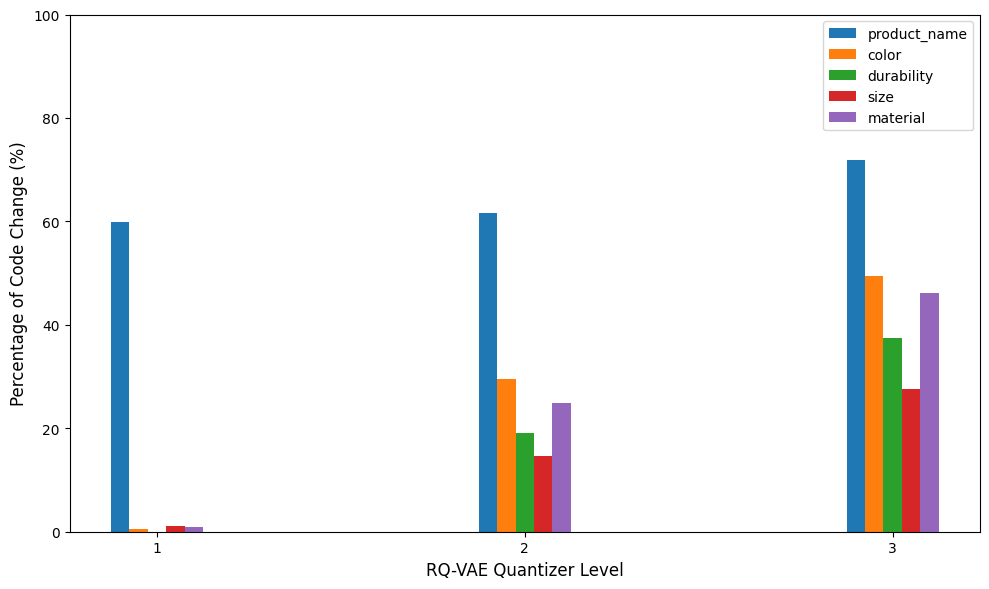

In [ ]:
plot_perturbation_result_combined(perturb_result_1)

### Change 2 attributes

In [ ]:
perturb_columns = itertools.combinations(['product_name', 'color',	'durability',	'size',	'material'], 2)
perturb_columns = [list(i) for i in list(perturb_columns)]
perturb_columns

[['product_name', 'color'],
 ['product_name', 'durability'],
 ['product_name', 'size'],
 ['product_name', 'material'],
 ['color', 'durability'],
 ['color', 'size'],
 ['color', 'material'],
 ['durability', 'size'],
 ['durability', 'material'],
 ['size', 'material']]

In [ ]:
perturb_result_2 = get_perturb_result(perturb_columns=perturb_columns)

Purterbation: product_name+color
Purterbation: product_name+durability
Purterbation: product_name+size
Purterbation: product_name+material
Purterbation: color+durability
Purterbation: color+size
Purterbation: color+material
Purterbation: durability+size
Purterbation: durability+material
Purterbation: size+material


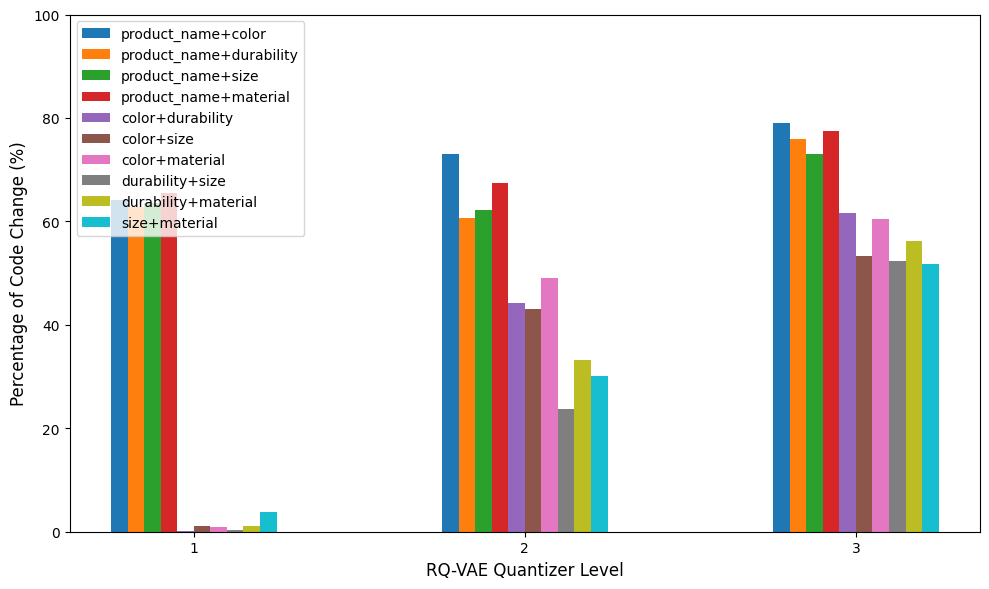

In [ ]:
plot_perturbation_result_combined(perturb_result_2)

### Change 3 attributes

In [ ]:
perturb_columns = itertools.combinations(['product_name', 'color',	'durability',	'size',	'material'], 3)
perturb_columns = [list(i) for i in list(perturb_columns)]
perturb_columns

[['product_name', 'color', 'durability'],
 ['product_name', 'color', 'size'],
 ['product_name', 'color', 'material'],
 ['product_name', 'durability', 'size'],
 ['product_name', 'durability', 'material'],
 ['product_name', 'size', 'material'],
 ['color', 'durability', 'size'],
 ['color', 'durability', 'material'],
 ['color', 'size', 'material'],
 ['durability', 'size', 'material']]

In [ ]:
perturb_result_3 = get_perturb_result(perturb_columns=perturb_columns)

Purterbation: product_name+color+durability
Purterbation: product_name+color+size
Purterbation: product_name+color+material
Purterbation: product_name+durability+size
Purterbation: product_name+durability+material
Purterbation: product_name+size+material
Purterbation: color+durability+size
Purterbation: color+durability+material
Purterbation: color+size+material
Purterbation: durability+size+material


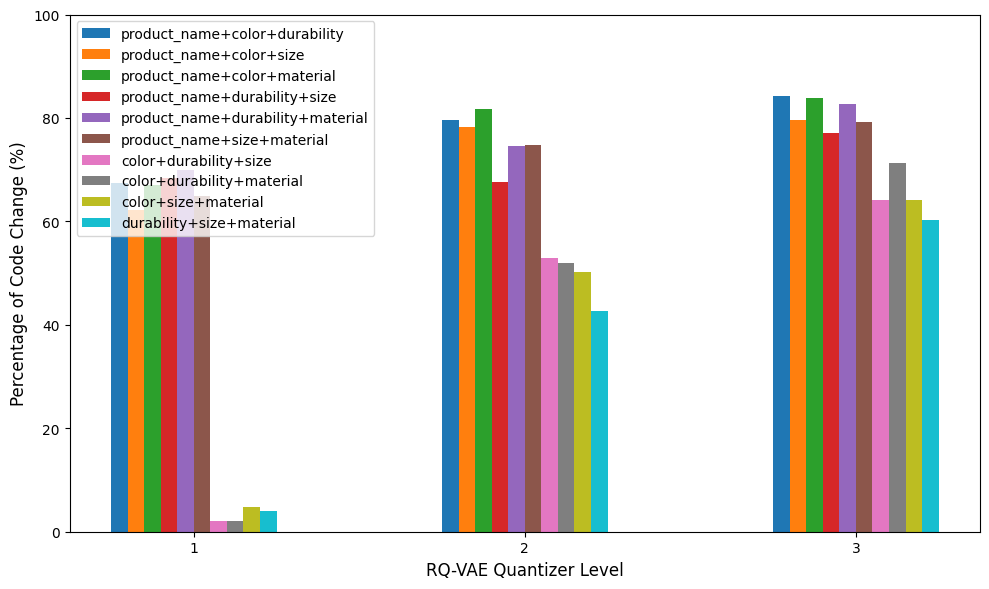

In [ ]:
plot_perturbation_result_combined(perturb_result_3)

### Change 4 attributes

In [ ]:
perturb_columns = itertools.combinations(['product_name', 'color',	'durability',	'size',	'material'], 4)
perturb_columns = [list(i) for i in list(perturb_columns)]
perturb_columns

[['product_name', 'color', 'durability', 'size'],
 ['product_name', 'color', 'durability', 'material'],
 ['product_name', 'color', 'size', 'material'],
 ['product_name', 'durability', 'size', 'material'],
 ['color', 'durability', 'size', 'material']]

In [ ]:
perturb_result_4 = get_perturb_result(perturb_columns=perturb_columns)

Purterbation: product_name+color+durability+size
Purterbation: product_name+color+durability+material
Purterbation: product_name+color+size+material
Purterbation: product_name+durability+size+material
Purterbation: color+durability+size+material


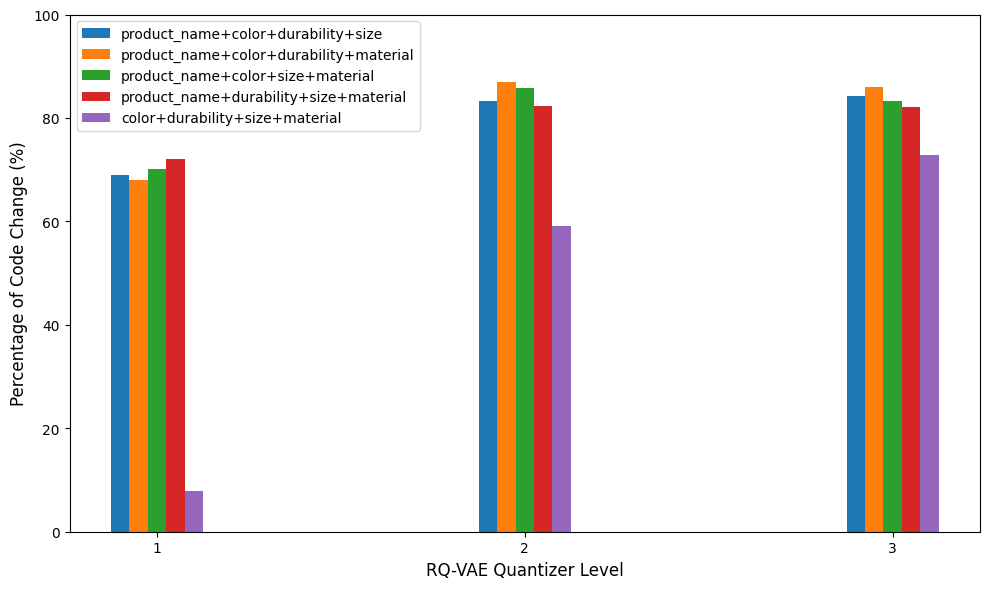

In [ ]:
plot_perturbation_result_combined(perturb_result_4)

### Change 5 attributes

In [ ]:
perturb_columns = itertools.combinations(['product_name', 'color',	'durability',	'size',	'material'], 5)
perturb_columns = [list(i) for i in list(perturb_columns)]
perturb_columns

[['product_name', 'color', 'durability', 'size', 'material']]

In [ ]:
perturb_result_5 = get_perturb_result(perturb_columns=perturb_columns)

Purterbation: product_name+color+durability+size+material


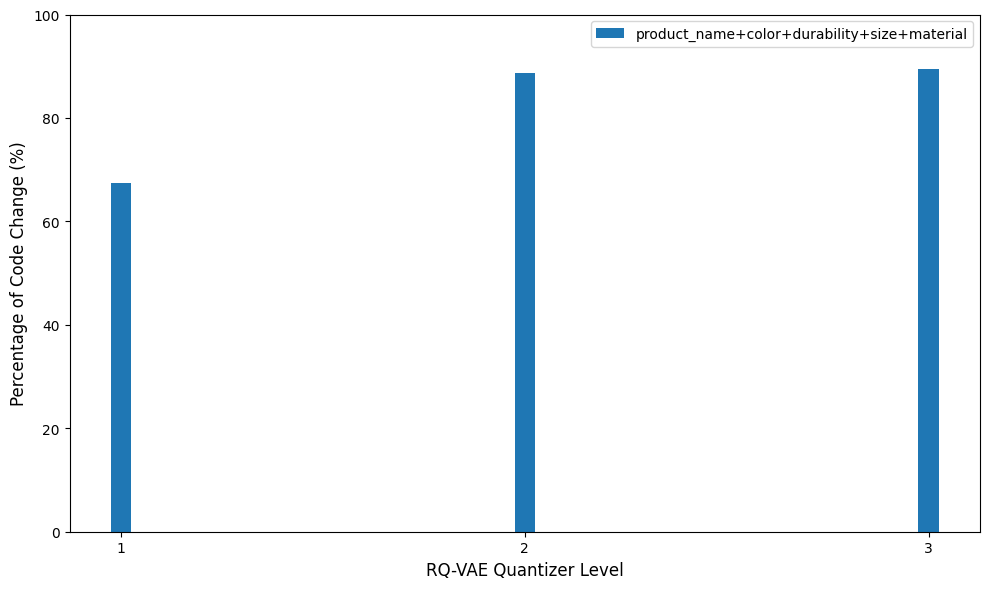

In [ ]:
plot_perturbation_result_combined(perturb_result_5)

###